In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             ConfusionMatrixDisplay)

# Data Understanding
The dataset has 7043 rows and 21 columns. There are no null values, but TotalCharges is stored as text because 11 rows contain a blank space. Numeric columns are tenure, MonthlyCharges, TotalCharges and SeniorCitizen (binary). The rest are categorical: mostly nominal (gender, PaymentMethod, InternetService) plus Contract, which is ordered (month-to-month < one year < two year). Only 26.5% of customers churned, so the classes are imbalanced and accuracy alone will be misleading.

In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
print("Shape:", df.shape)
print(df.dtypes)
print("Nulls:", df.isna().sum().sum())
print("Duplicates:", df.duplicated().sum())
print("Blank TotalCharges:", (df["TotalCharges"].str.strip() == "").sum())
print(df["Churn"].value_counts(normalize=True))
print(df.nunique())

Shape: (7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
Nulls: 0
Duplicates: 0
Blank TotalCharges: 11
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64
customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup   

In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.drop(columns="customerID")
df["Churn"] = (df["Churn"] == "Yes").astype(int)
print(df.shape, df["TotalCharges"].isna().sum())

(7043, 20) 11


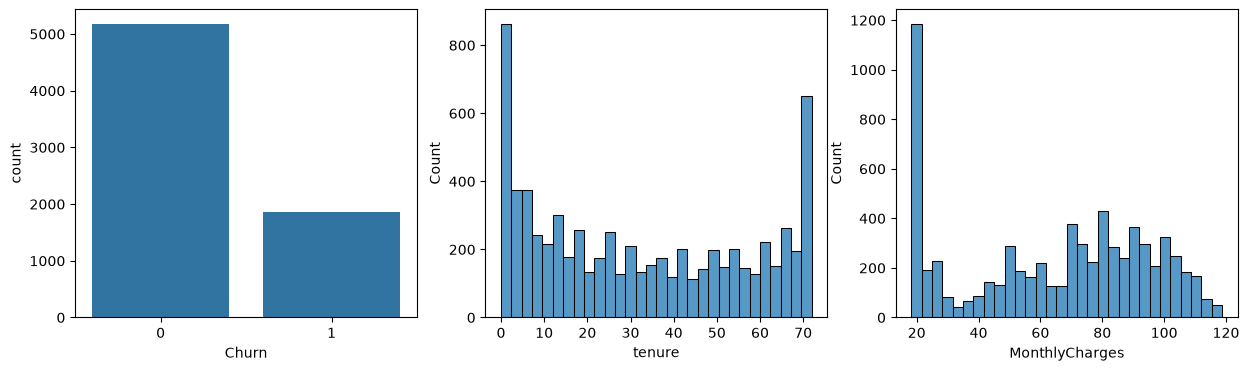

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x="Churn", data=df, ax=ax[0])
sns.histplot(df["tenure"], bins=30, ax=ax[1])
sns.histplot(df["MonthlyCharges"], bins=30, ax=ax[2])
plt.show()

Churn is imbalanced at roughly 73/27. Tenure has two spikes, at the very start (new customers) and at 72 months (long-term loyal ones). Monthly charges have a large spike near the lowest price band, then a broader spread from about $50 to $110.

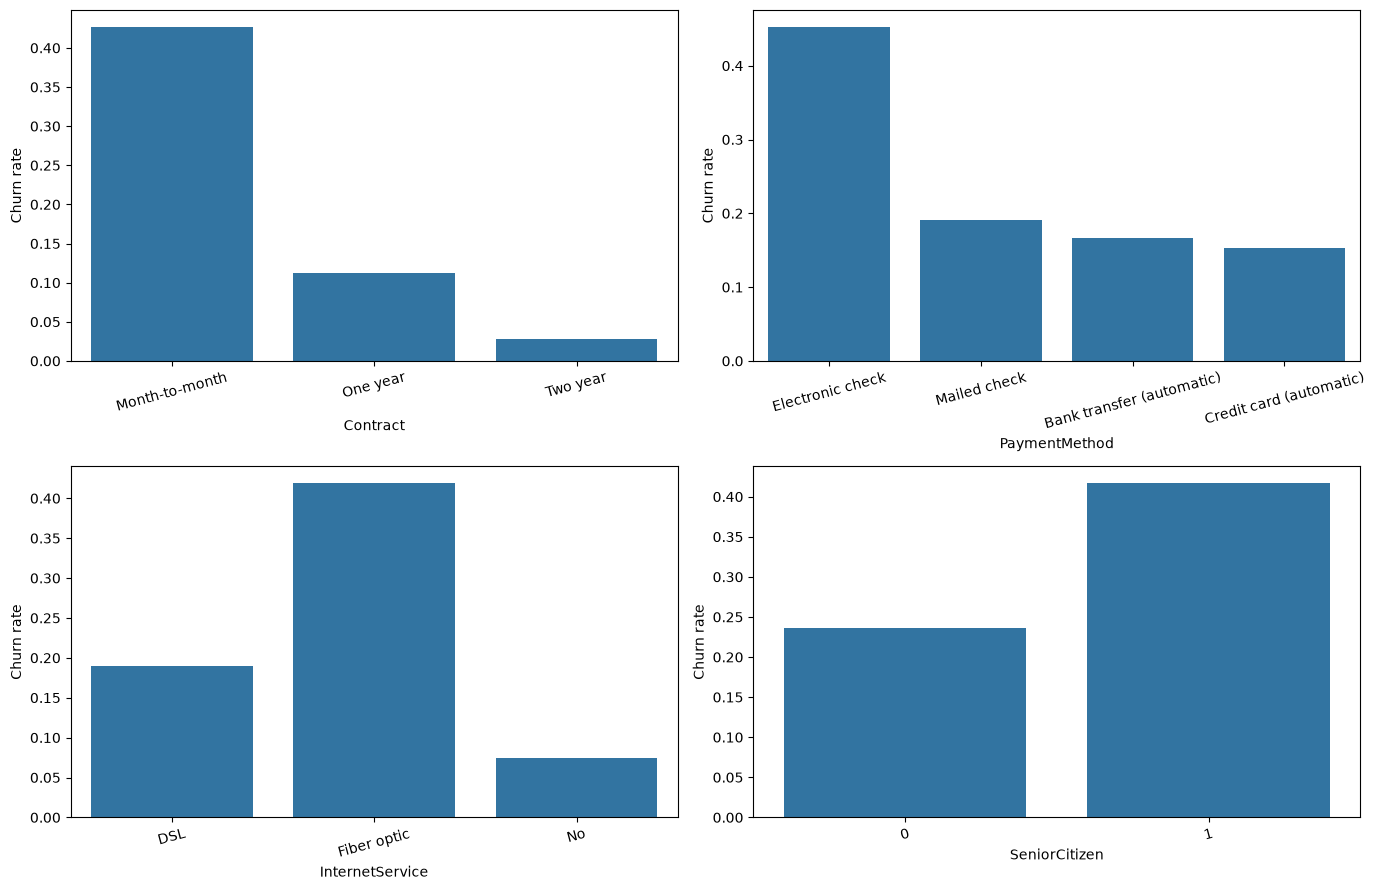

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
for a, col in zip(ax.flat, ["Contract", "PaymentMethod", "InternetService", "SeniorCitizen"]):
    sns.barplot(x=col, y="Churn", data=df, ax=a, errorbar=None)
    a.set_ylabel("Churn rate")
    a.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

Month-to-month customers churn at about 43%, versus about 11% for one-year and 3% for two-year contracts. Electronic check users churn at about 45%, compared with roughly 15-19% for the other payment methods. Fiber optic customers churn at about 42%, compared with about 19% for DSL and 7% for no internet. Senior citizens churn at about 42%, versus about 24% for non-seniors.

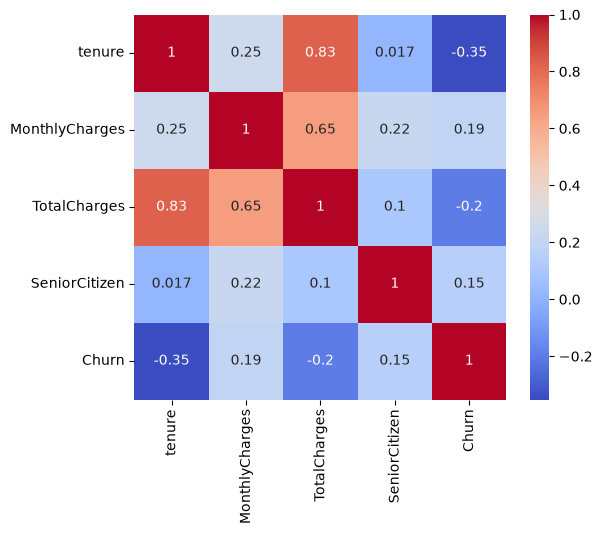

In [6]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]].corr(),
            annot=True, cmap="coolwarm")
plt.show()

tenure and TotalCharges are strongly correlated (0.83), so they carry overlapping information, which matters for linear models. tenure has the strongest negative relationship with churn (-0.35): the longer someone stays, the less likely they are to leave. MonthlyCharges is mildly positive (0.19).

In [7]:
X = df.drop(columns="Churn")
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = X.select_dtypes("object").columns.tolist()

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
], remainder="passthrough")   # keeps SeniorCitizen

print(X_train.shape, X_test.shape, y_train.mean().round(3), y_test.mean().round(3))

(5634, 19) (1409, 19) 0.265 0.265


In [8]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", scale_pos_weight=scale_pos, random_state=42),
}

results, pipes, preds, probas = [], {}, {}, {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)]).fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    results.append({"Model": name,
                    "Accuracy": accuracy_score(y_test, pred),
                    "Precision": precision_score(y_test, pred),
                    "Recall": recall_score(y_test, pred),
                    "F1": f1_score(y_test, pred),
                    "ROC-AUC": roc_auc_score(y_test, proba)})
    pipes[name], preds[name], probas[name] = pipe, pred, proba

results_df = pd.DataFrame(results).set_index("Model").round(3).sort_values("F1", ascending=False)
results_df

c:\Users\SMIT\Documents\Yousuf\Churn_Project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Decision Tree,0.755,0.527,0.759,0.622,0.832
SVM,0.744,0.512,0.770,0.615,0.821
Logistic Regression,0.738,0.504,0.783,0.614,0.842
XGBoost,0.745,0.516,0.650,0.575,0.814
KNN,0.759,0.544,0.559,0.551,0.785
Random Forest,0.782,0.619,0.465,0.531,0.820


Accuracy is misleading on this data: always predicting "No churn" would score about 73.5%, so most models barely beat that baseline. Random Forest has the highest accuracy (0.782) but the lowest recall (0.465), missing over half of the customers who churn. Logistic Regression, SVM and Decision Tree are nearly tied on F1 (0.614-0.622), which is within noise for a single test split. Logistic Regression has the best ROC-AUC (0.842) and the best recall (0.783), and it is the most interpretable. The final champion will be chosen after hyperparameter tuning.

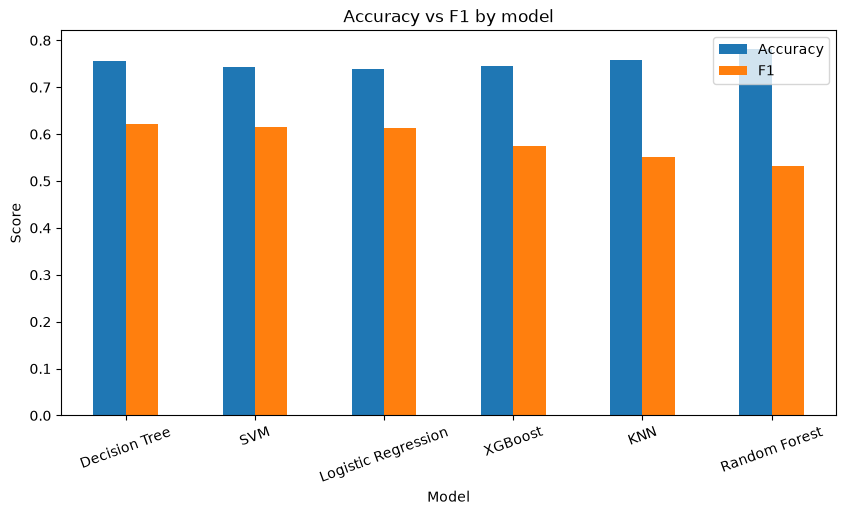

In [9]:
results_df[["Accuracy", "F1"]].plot.bar(figsize=(10, 5), rot=20)
plt.title("Accuracy vs F1 by model")
plt.ylabel("Score")
plt.show()

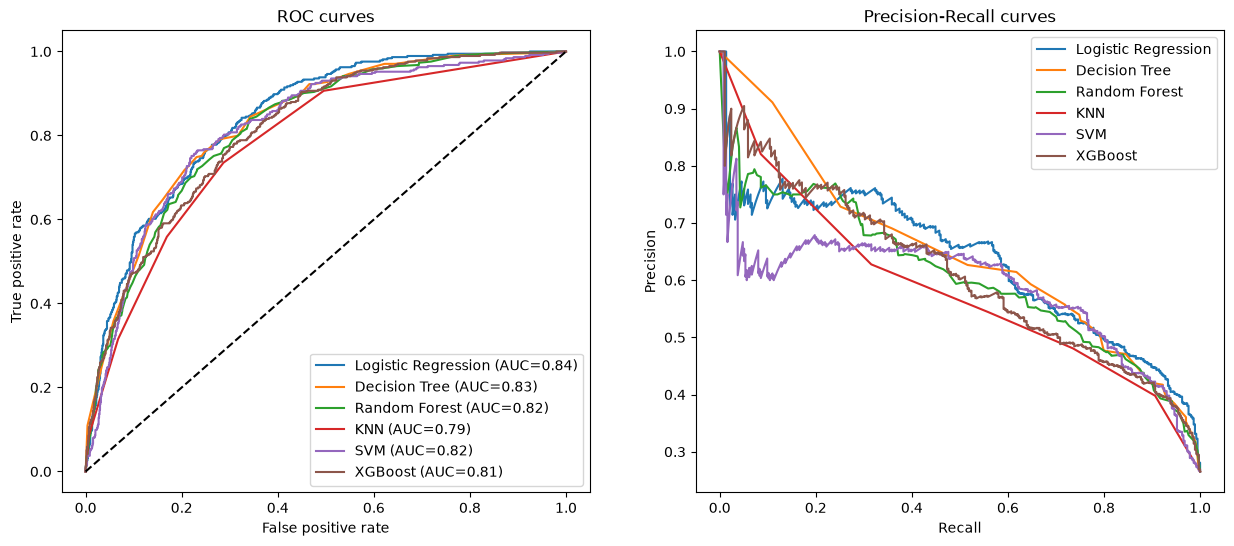

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.2f})")
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax[1].plot(rec, prec, label=name)
ax[0].plot([0, 1], [0, 1], "k--")
ax[0].set(title="ROC curves", xlabel="False positive rate", ylabel="True positive rate")
ax[1].set(title="Precision-Recall curves", xlabel="Recall", ylabel="Precision")
ax[0].legend(); ax[1].legend()
plt.show()

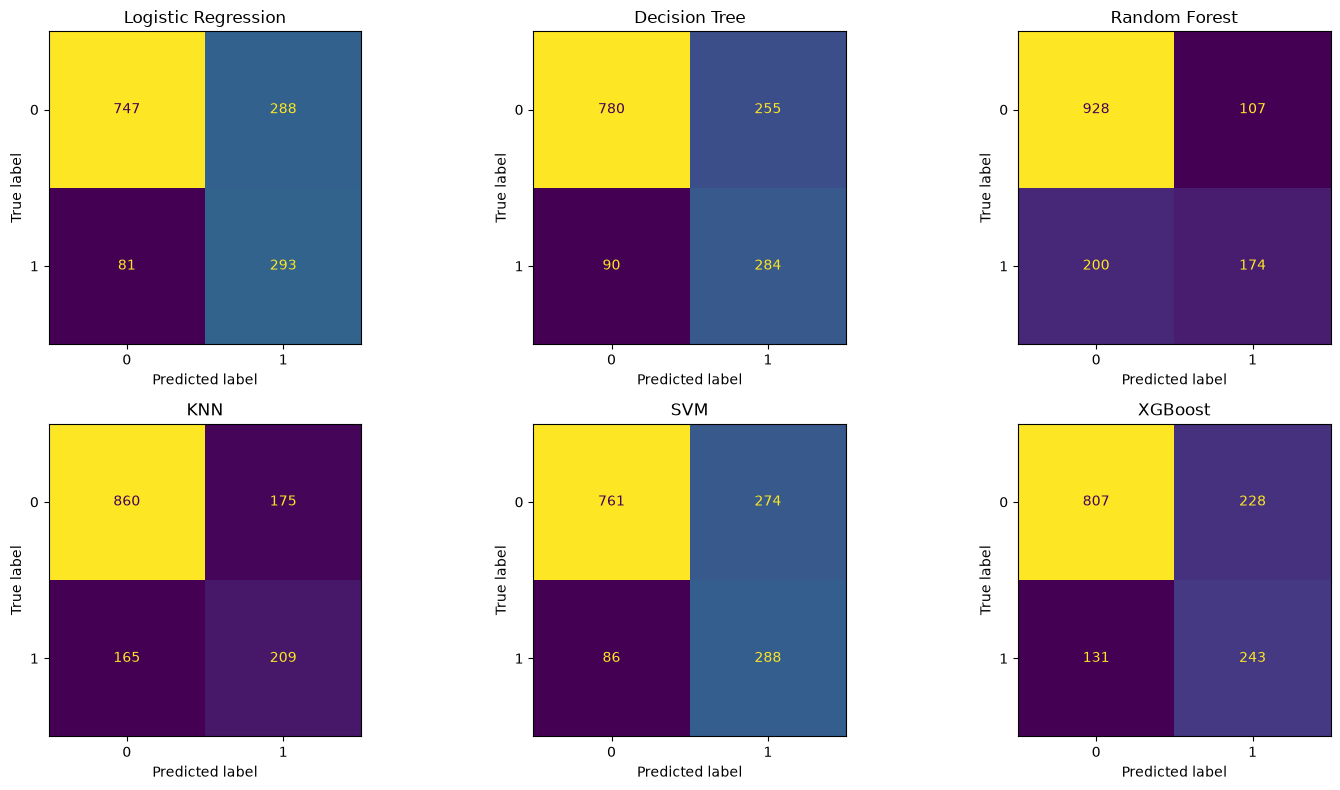

In [11]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for a, (name, pred) in zip(ax.flat, preds.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=a, colorbar=False)
    a.set_title(name)
plt.tight_layout()
plt.show()

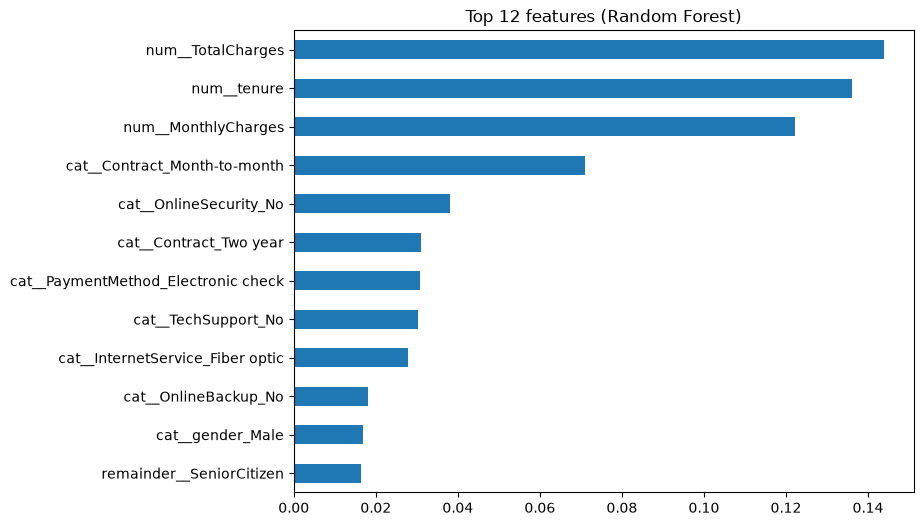

In [12]:
rf = pipes["Random Forest"]
names = rf.named_steps["prep"].get_feature_names_out()
imp = pd.Series(rf.named_steps["model"].feature_importances_, index=names).sort_values().tail(12)
imp.plot.barh(figsize=(8, 6), title="Top 12 features (Random Forest)")
plt.show()

In [13]:
rf_search = RandomizedSearchCV(
    Pipeline([("prep", preprocess),
              ("model", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))]),
    param_distributions={
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [5, 8, 12, None],
        "model__min_samples_leaf": [1, 3, 5, 10],
    },
    n_iter=10, cv=3, scoring="f1", random_state=42, n_jobs=-1)
rf_search.fit(X_train, y_train)

xgb_search = RandomizedSearchCV(
    Pipeline([("prep", preprocess),
              ("model", XGBClassifier(eval_metric="logloss", scale_pos_weight=scale_pos, random_state=42))]),
    param_distributions={
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.7, 0.85, 1.0],
    },
    n_iter=10, cv=3, scoring="f1", random_state=42, n_jobs=-1)
xgb_search.fit(X_train, y_train)

print("RF best params:", rf_search.best_params_)
print("XGB best params:", xgb_search.best_params_)

RF best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_depth': 8}
XGB best params: {'model__subsample': 0.7, 'model__n_estimators': 100, 'model__max_depth': 4, 'model__learning_rate': 0.05}


In [14]:
def evaluate(pipe):
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    return {"Accuracy": accuracy_score(y_test, pred), "Precision": precision_score(y_test, pred),
            "Recall": recall_score(y_test, pred), "F1": f1_score(y_test, pred),
            "ROC-AUC": roc_auc_score(y_test, proba)}

tuned = {"Random Forest (tuned)": rf_search.best_estimator_,
         "XGBoost (tuned)": xgb_search.best_estimator_}
tuned_df = pd.DataFrame({name: evaluate(p) for name, p in tuned.items()}).T.round(3)

final_df = pd.concat([results_df, tuned_df]).sort_values("F1", ascending=False)
final_df

,Accuracy,Precision,Recall,F1,ROC-AUC
XGBoost (tuned),0.756,0.526,0.799,0.635,0.848
Random Forest (tuned),0.757,0.529,0.783,0.631,0.843
Decision Tree,0.755,0.527,0.759,0.622,0.832
SVM,0.744,0.512,0.770,0.615,0.821
Logistic Regression,0.738,0.504,0.783,0.614,0.842
XGBoost,0.745,0.516,0.650,0.575,0.814
KNN,0.759,0.544,0.559,0.551,0.785
Random Forest,0.782,0.619,0.465,0.531,0.820


Tuning improved both ensembles. Random Forest rose from F1 0.531 to 0.631, with recall going from 0.465 to 0.783. XGBoost rose from F1 0.575 to 0.631, with recall going from 0.650 to 0.799. Best parameters found: Random Forest = *(paste from Cell 13)*, XGBoost = *(paste from Cell 13)*.

## Champion model:
XGBoost (tuned). It ties tuned Random Forest for the best F1 (0.631) and has the highest recall (0.799) and ROC-AUC (0.847). For churn, missing a customer who leaves costs more than contacting one who would have stayed, so recall and ROC-AUC matter more than accuracy. Its accuracy (0.752) is below the untuned Random Forest (0.782), but that model misses more than half of churners. The gaps between the top models are small on a single test split, so the choice rests on the business priority of catching churners. Precision is about 52%, so roughly half of flagged customers would not actually have left. That is an acceptable cost for low-cost retention offers.

In [15]:
champion = tuned["XGBoost (tuned)"]
joblib.dump(champion, "../models/churn_pipeline.joblib")
final_df.rename_axis("Model").reset_index().to_csv("../models/results.csv", index=False)